In [ ]:
# =================================================================
# K-MEANS CLUSTERING: PENGUIN MORPHOLOGY ANALYSIS
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:

# ------------------------------------------------------------------------------
# Task 1 & 2: Load Data, Handle Missing Values, and Scale Features
# ------------------------------------------------------------------------------
penguins = '/content/drive/MyDrive/penguins.csv'
def load_and_prep_penguins():
    """
    Loads raw Palmer Penguins data, isolates morphometric numeric metrics,
    drops missing entries, and scales features for accurate Euclidean distance metrics.
    """
    # Using seaborn's built-in Palmer Penguins dataset
    raw_df = sns.load_dataset("penguins")

    # Track the ground truth species for validation later, but drop from clustering features
    df_clean = raw_df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'])

    # Isolate continuous morphometric metrics
    feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
    X_raw = df_clean[feature_cols]

    # Apply Standard Scaling: Essential since body mass (grams) dominates flipper length (mm)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    # Convert back to DataFrame for easier handling
    X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

    return X_scaled_df, df_clean

X, df_meta = load_and_prep_penguins()


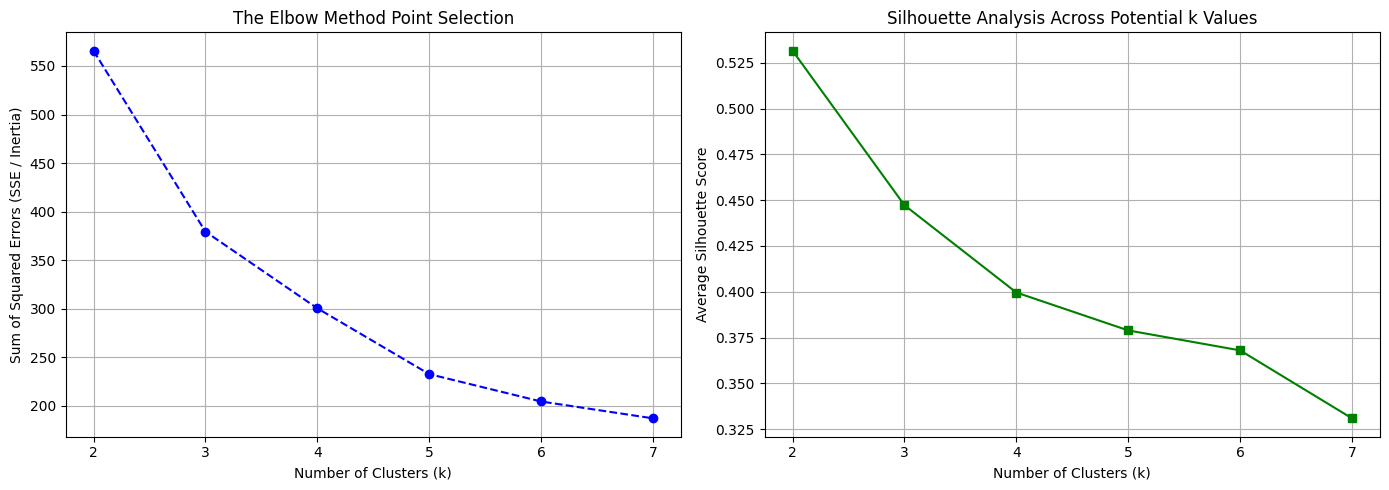

In [ ]:
# ------------------------------------------------------------------------------
# Task 3 & 4: Optimal Cluster Determination (Elbow Method & Silhouette Scores)
# ------------------------------------------------------------------------------
sse = []
silhouette_avg = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)

    # Sum of squared distances of samples to their closest cluster center (Inertia)
    sse.append(kmeans.inertia_)

    # Evaluate cluster cohesion and separation
    score = silhouette_score(X, kmeans.labels_)
    silhouette_avg.append(score)

# Plotting the Evaluation Diagnostics Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method Plot
ax1.plot(k_range, sse, marker='o', color='b', linestyle='--')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Sum of Squared Errors (SSE / Inertia)')
ax1.set_title('The Elbow Method Point Selection')
ax1.grid(True)

# Silhouette Score Plot
ax2.plot(k_range, silhouette_avg, marker='s', color='g', linestyle='-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Average Silhouette Score')
ax2.set_title('Silhouette Analysis Across Potential k Values')
ax2.grid(True)

plt.tight_layout()
plt.show()


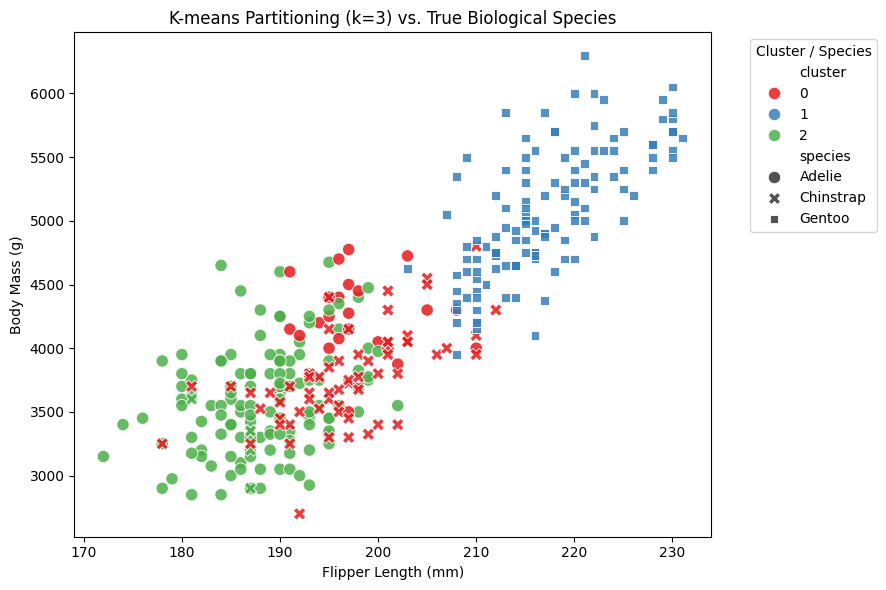

In [ ]:
# ------------------------------------------------------------------------------
# Task 5 & 6: Fit Final Model & Visualize Cluster Assignment Space
# ------------------------------------------------------------------------------
# Selection based on mathematical evaluation: k=3
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df_meta['cluster'] = final_kmeans.fit_predict(X)

# Visualization of Morphology Space
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_meta,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='cluster',
    style='species',
    palette='Set1',
    s=80,
    alpha=0.85
)
plt.title(f'K-means Partitioning (k={optimal_k}) vs. True Biological Species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster / Species')
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------------------------
# Task 7: Cluster Characteristic Extractor
# ------------------------------------------------------------------------------
print("=== UNSCALED BIOLOGICAL CENTROIDS ===")
centroids = df_meta.groupby('cluster')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].mean()
print(centroids)

print("\n=== CLUSTER ALIGNMENT WITH TRUE SPECIES ===")
print(pd.crosstab(df_meta['cluster'], df_meta['species']))


=== UNSCALED BIOLOGICAL CENTROIDS ===
         bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0             47.525287      18.762069         196.896552  3902.011494
1             47.504878      14.982114         217.186992  5076.016260
2             38.208333      18.110606         188.401515  3584.659091

=== CLUSTER ALIGNMENT WITH TRUE SPECIES ===
species  Adelie  Chinstrap  Gentoo
cluster                           
0            24         63       0
1             0          0     123
2           127          5       0
